<b>6.9 Image Classification - IMT575</b>
Steve Gonzales<p>
## UNCOMMENT OUT `.summary()`

# Deep Learning: Image Classification

People rarely train deep neural networks from scratch (with random initialization) these days. Instead, we often use some form of [transfer learning](http://cs231n.github.io/transfer-learning/), which uses a [pretrained network](https://keras.rstudio.com/articles/applications.html) to save training time and improve model prediction. In this assignment, we will explore and compare two widely-used transfer learning techniques: feature extraction and fine-tuning.


**Before You Start**

Please make sure you have [numpy](https://numpy.org/), [Keras](https://keras.io/) and one of its backend engines (e.g., [TensorFlow](https://www.tensorflow.org/install/)).


**Dataset and Task**

We will use the [Viziometrics dataset](https://canvas.uw.edu/files/59549223/download?download_frd=1) ([paper1](https://ieeexplore.ieee.org/abstract/document/7888968), [paper2](https://arxiv.org/abs/1908.07465)). The dataset contains 2k+ images from scientific publications that are hand-labeled as one of the five classes: equation, photo, scheme, table, and visualization. The train, validation, and test set has already been splitted for us. Our task is to train neural network classifiers to predict the five labels.


**How to Complete This Assignment and What to Turn In**

We have provided some starter code. Each task you need to complete is marked with a red school bag 🎒and is worth a few points. Each task will either ask you to print something or report certain metrics. **Please submit your completed notebook with the code and the required output of each task. You will not receive full points if either code or output is missing.**

👉 **_Please start early. It takes time to train these networks._**



## 0. Load the Data

🎒<font color='red'>(1 point)</font> Put the dataset in the same folder as this notebook, then run the following starter code. Because our training set contains a lot of images, we use [`ImageDataGenerator.flow_from_directory()`](https://keras.io/preprocessing/image/) to load images in batches. Please refer to [Vijayabhaskar's tutorial](https://medium.com/@vijayabhaskar96/tutorial-image-classification-with-keras-flow-from-directory-and-generators-95f75ebe5720) to understand the parameterization of the generators. This starter code should output something like:

```
Found xxx images belonging to 5 classes.
Found xxx images belonging to 5 classes.
Found xxx images belonging to 5 classes.
```

Please include this output in your submission.

In [195]:
import os, random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import ResNet50, decode_predictions
from tensorflow.keras import layers
from tensorflow.keras.models import Model, Sequential
from keras.callbacks import ModelCheckpoint, EarlyStopping

os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [196]:
# create train, validation, and test generators from our image directory
datagen = ImageDataGenerator()
train_generator = datagen.flow_from_directory(
  directory=r"./viziometrics/train/",
  target_size=(224, 224),
  color_mode="rgb",
  batch_size=32,
  class_mode="categorical",
  shuffle=False,
  seed=42
)
val_generator = datagen.flow_from_directory(
  directory=r"./viziometrics/val/",
  target_size=(224, 224),
  color_mode="rgb",
  batch_size=32,
  class_mode="categorical",
  shuffle=False,
  seed=42
)
test_generator = datagen.flow_from_directory(
  directory=r"./viziometrics/test/",
  target_size=(224, 224),
  color_mode="rgb",
  batch_size=1,
  class_mode="categorical",
  shuffle=False,
  seed=42
)

Found 2733 images belonging to 5 classes.
Found 1571 images belonging to 5 classes.
Found 1563 images belonging to 5 classes.


🎒<font color='red'>(2 point)</font> 
Let's look at some random images to see what kind of data we're working with.

All figures come from the scientific literature.

Run the code below to show some random images.

But then modify the indicated line to choose 15 indices explicitly.  Find 3 diagrams, 3 plots, 3 photos, 3 tables, and 3 equations.  Just trial and error is fine -- no need to write code to do this unless you want to.  The idea is just to explore the data a little. 

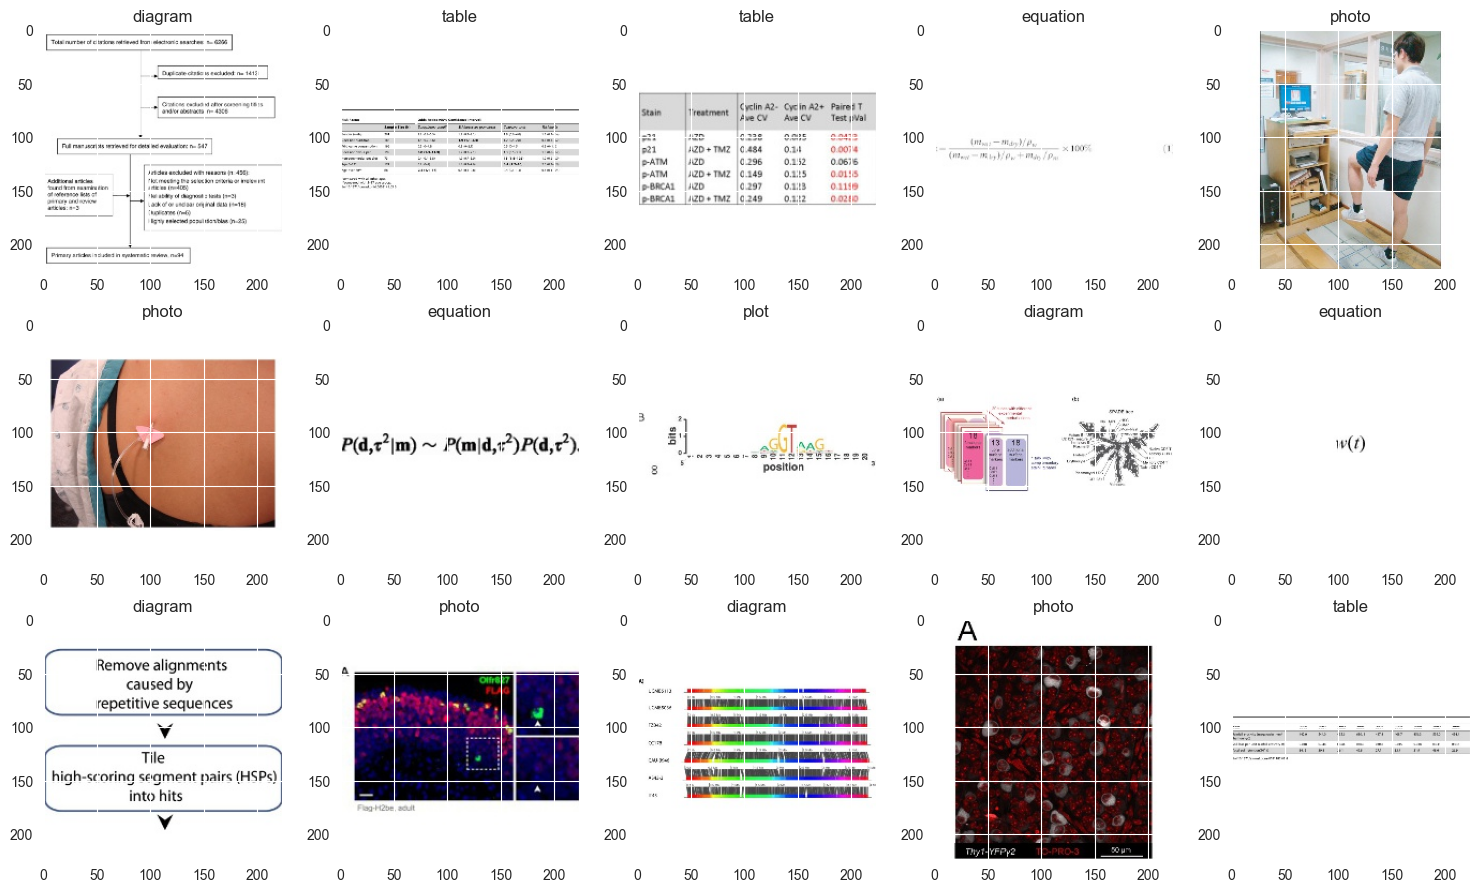

In [197]:
from matplotlib import pyplot as plt

rows, cols = 3,5
fig, axes = plt.subplots(rows,cols,figsize=(cols*3,rows*3))
fig.tight_layout()
labels = ["equation", "photo", "diagram", "table", "plot"]
# Choose your indexes to look at -- a list of rows*cols numbers
imageidx = np.random.randint(np.random.randint(len(test_generator)), size=rows*cols)
for i in range(rows*cols):
    plt.subplot(rows,cols,i+1)
    (imgdata, onehotlabel) = test_generator[imageidx[i]]
    img = imgdata.squeeze().astype(np.uint8)      # get rid of singleton dimension; cast type so imshow is happy
    fig = plt.imshow(img)                         # show the image
    lbl = labels[np.where(onehotlabel==1)[1][0]]  # find the index of the class label; look up the string
    plt.title(lbl)                                # add a title with the class label

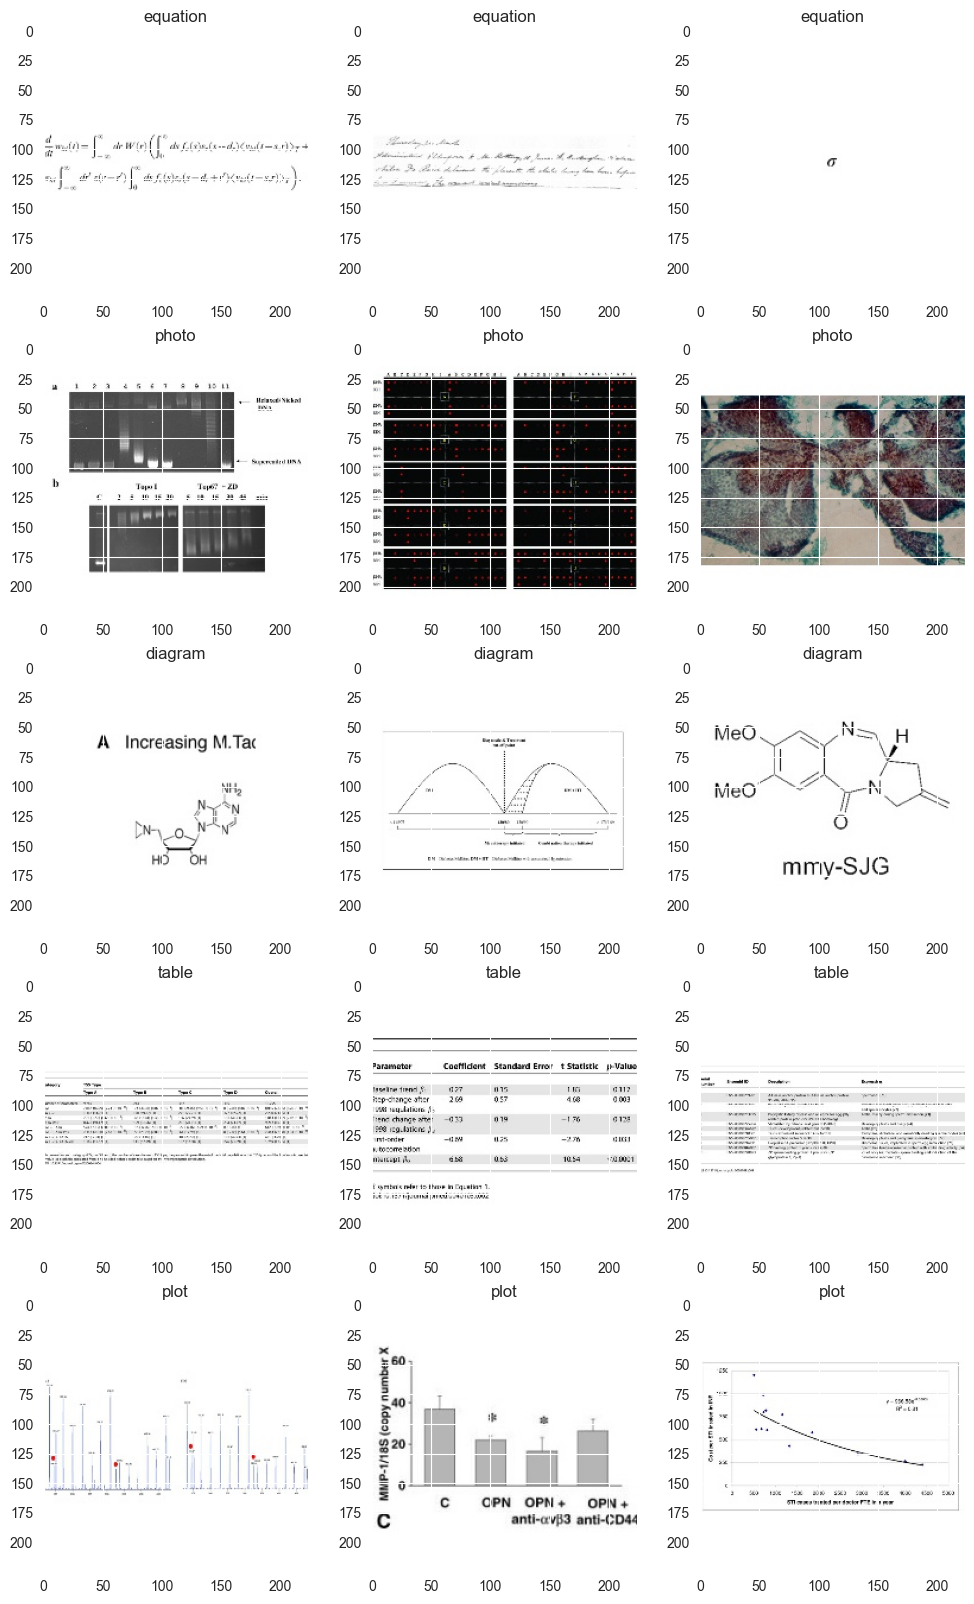

In [198]:
# Pick 15 random images, 3 from each label class
num_images, image_idx = 0, 0
images = {label: [] for label in labels}
while num_images < 15:
    image_idx += 1
    (img_data, onehot_label) = test_generator[image_idx]
    label = labels[np.where(onehot_label==1)[1][0]]
    if len(images[label]) < 3:
        num_images += 1
        images[label].append(image_idx)
    # Show the images we selected
cols, rows = 3, 5
fig, axes = plt.subplots(rows,cols,figsize=(cols*4,rows*4))
for label in labels:
    for i in range(cols):
        plt.subplot(rows,cols,labels.index(label)*3+i+1)
        (img_data, onehot_label) = test_generator[images[label][i]]
        img = img_data.squeeze().astype(np.uint8)      # get rid of singleton dimension; cast type so imshow is happy
        fig = plt.imshow(img)                         # show the image
        plt.title(label)                              # add a title with the class label

## 1. Feature Extraction (20 points)

We will use a pretrained network (ResNet50) to extract features from the images. Then we will train a not-so-deep neural network on the features (X) and the labels (y). Finally we will evaluate our network. Please read [Vikas' tutorial on feature extraction](https://www.learnopencv.com/keras-tutorial-transfer-learning-using-pre-trained-models/) for code examples on feature extraction; we will use the same pipeline here.

🎒<font color='red'>(1 point)</font> Run the following code to load a [ResNet50 network](https://keras.rstudio.com/reference/application_resnet50.html) pretrained on the [ImageNet](http://www.image-net.org/) dataset. 

The last layer of ResNet50 is responsible for assigning a class label to each image.  We don't want these class labels -- we want the big interesting vectors before the final prediction.  We'll get this in the next cell.

Use `model.summary()` to inspect the ResNet50 architecture. This function should print out all the layers - their names, types, output shapes etc. You now know what most (but perhaps not all) of these layers do!

Please include the printout in your submission.

In [199]:
# download the pre-trained ResNet50 model
resnet = keras.applications.resnet.ResNet50(weights='imagenet', input_shape=(224,224,3))

# inspect the ResNet50 architecture
# resnet.summary()

🎒<font color='red'>(1 point)</font>The following code builds a new model starting from the first layer of ResNet50 and ending with the

So the output of our new model will not be ResNet50 class predictions (which we don't care about)

But instead the long vectors just before the predictions.

In the summary above, we see the name of this next-to-last layer is "avg_pool"

We want the outputs from this layer.  

Scroll down to see the last layer, and add a comment to the code that shows the total number of parameters of this model (which you can see at the bottom).

In [200]:
# The Output Shape of avg_pool GlobalAveragePool is (None, 2048)
layer_name = 'avg_pool'
resnet_embedder = Model(inputs=resnet.input, outputs=resnet.get_layer(layer_name).output)
# inspect the adjusted model
# resnet_embedder.summary()
# scroll down to see the last layer

🎒<font color='red'>(1 points)</font> Use our new "all-but-last-layer" version of ResNet50 to convert all images into embedded vectors.

Sometimes you'll see this process called "extracting features." The idea is just to take an image, pass it through all 49 layers of ResNet50, and spit out a vector.  We'll then use these vectors as inputs to our own custom model.

Print the shape of the extracted features.

👉 We use [`model.predict()`](https://keras.io/models/sequential/#predict_generator) to run the model and convert a bunch of images into vectors.

👉 This step is slow when you use the full training set. Setting `verbose=1` can make a wait a bit easier.

In [201]:
train_features = resnet_embedder.predict(train_generator, verbose=1) # takes ~4min on my

/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


86/86 ━━━━━━━━━━━━━━━━━━━━ 32s 369ms/step


In [202]:
val_features = resnet_embedder.predict(val_generator, verbose=1)
test_features = resnet_embedder.predict(test_generator, verbose=1)

50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 363ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step


In [203]:
print(f'Shape of train_features: {train_features.shape}')
print(f'Shape of val_features: {val_features.shape}')
print(f'Shape of test_features: {test_features.shape}')

Shape of train_features: (2733, 2048)
Shape of val_features: (1571, 2048)
Shape of test_features: (1563, 2048)


🎒<font color='red'>(1 points)</font> Read the class labels from the generators. Print `test_labels`

In [204]:
# read the class labels from the generators
train_labels = train_generator.classes
val_labels = val_generator.classes
test_labels = test_generator.classes

print(f'Class labels for train set: {train_labels}')
print(f'Class labels for validation set: {val_labels}')
print(f'Class labels for test set: {test_labels}')

Class labels for train set: [0 0 0 ... 4 4 4]
Class labels for validation set: [0 0 0 ... 4 4 4]
Class labels for test set: [0 0 0 ... 4 4 4]


🎒<font color='red'>(3 points)</font> The labels are represented as one big array of values: value 0 for airplane not one-hot encoded. We need to one-hot encode these labels and they will be the y that our model will predict.

In [205]:
# get one-hot encoding of labels
def get_one_hot(labels, nb_classes):
    res = np.eye(nb_classes)[np.array(labels).reshape(-1)]
    return res.reshape(list(labels.shape)+[nb_classes])

# use get_one_hot()
NUM_CLASSES = 5
train_y = get_one_hot(train_labels, NUM_CLASSES)
val_y = get_one_hot(val_labels, NUM_CLASSES)
test_y = get_one_hot(test_labels, NUM_CLASSES)
print(train_y)

[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]]


🎒<font color='red'>(3 points)</font> Define a simple neural network that contains a few layers. There is a three-layer example network below. Please modify this network - you can add layers, remove layers, or change some of the parameters. Please print out your model architecture using `model.summary()`.

In [206]:
# create our model: a not-so-deep neural network
simple_nn_model = Sequential()
DIM = train_features.shape[1] # this is the size of the feature vector we get from ResNet50
# input layer takes arrays of shape (*, DIM)
# todo: please modify this network to define your own model
simple_nn_model.add(layers.Dense(500, activation="relu", input_shape=(DIM,)))
simple_nn_model.add(layers.Dropout(0.2, noise_shape=None, seed=42))
simple_nn_model.add(layers.Dense(NUM_CLASSES, activation="softmax"))
simple_nn_model.summary()

/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_86 (Dense)                │ (None, 500)            │     1,024,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_58 (Dropout)            │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 5)              │         2,505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,027,005 (3.92 MB)

 Trainable params: 1,027,005 (3.92 MB)

 Non-trainable params: 0 (0.00 B)

🎒<font color='red'>(1 point)</font> Compile your model using [`model.compile()`](https://keras.io/models/model/#compile). Choose `sgd` optimizer and `categorical_crossentropy` loss. Set `metrics = ["accuracy"]`

In [207]:
# you need to compile the model before you can train it
simple_nn_model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
simple_nn_model.fit(
    x=train_features,
    y=train_y,
    epochs=10,
    batch_size=32,
    validation_data=(val_features, val_y),
    verbose=1
)
# Evaluate the model on test data and print accuracy
loss, accuracy = simple_nn_model.evaluate(test_features, test_y, verbose=0)
print(f'Test accuracy: {accuracy:.4f}')
# print out network architecture

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7714 - loss: 0.6757 - val_accuracy: 0.5824 - val_loss: 1.1916
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9161 - loss: 0.2660 - val_accuracy: 0.6098 - val_loss: 1.0341
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9241 - loss: 0.2274 - val_accuracy: 0.6346 - val_loss: 0.9092
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9394 - loss: 0.1936 - val_accuracy: 0.6505 - val_loss: 0.8940
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9446 - loss: 0.1777 - val_accuracy: 0.6684 - val_loss: 0.8542
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9426 - loss: 0.1639 - val_accuracy: 0.6824 - val_loss: 0.8417
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9535 - loss: 0.1507 - val_accuracy: 0.6957 - val_loss: 0.8151
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9533 - loss: 0.1451 - val_accuracy: 0.6996 - val_loss:

In [208]:
# Increased model capacity with more layers and units
nn_model_mod = Sequential()
nn_model_mod.add(layers.Dense(1024, activation="relu", input_shape=(DIM,)))
nn_model_mod.add(layers.BatchNormalization())
nn_model_mod.add(layers.Dropout(0.2))
nn_model_mod.add(layers.Dense(2048, activation="relu", input_shape=(DIM,)))
nn_model_mod.add(layers.BatchNormalization())
nn_model_mod.add(layers.Dropout(0.2))
nn_model_mod.add(layers.Dense(2048, activation="relu", input_shape=(DIM,)))
nn_model_mod.add(layers.BatchNormalization())
nn_model_mod.add(layers.Dropout(0.1))
nn_model_mod.add(layers.Dense(NUM_CLASSES, activation="softmax"))
nn_model_mod.summary()

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_88 (Dense)                │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_59 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 2048)           │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_60 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 2048)           │     4,196,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_61 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ (None, 5)              │        10,245 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,424,453 (32.14 MB)

 Trainable params: 8,414,213 (32.10 MB)

 Non-trainable params: 10,240 (40.00 KB)

In [209]:
# you need to compile the model before you can train it
nn_model_mod.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
# Evaluate the model on test data and print accuracy
loss, accuracy = nn_model_mod.evaluate(test_features, test_y, verbose=0)
print(f'Test accuracy: {accuracy:.4f}')

Test accuracy: 0.2156


🎒<font color='red'>(3 points)</font> Train the model you defined for about 10 epochs, or until the validation accuracy reaches 0.8 (whichever comes earlier). The model should be trained on `train_X` and `train_y`; it should be validated on `val_X` and `val_y`. Observe how the train accuracy and validation accuracy changes over epochs. Report (in a code comment) the best train and validation accuracy you've seen during training.

👉 Note that you can [check-point](https://keras.io/callbacks/#modelcheckpoint) model weights during training. After training, you can load back the weights of your best model.

use the `save_best_only` parameter and use `monitor='val_accuracy'` to define what "best" means.

In [210]:
# # save model weights while model is under training
nn_model_mod.save('nn_model_mod_best.keras')
checkpoint = ModelCheckpoint('nn_model_mod_best.keras', monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

nn_model_mod.fit(
    x=train_features, y=train_y,
    epochs=12, batch_size=32,
    validation_data=(val_features, val_y), verbose=1,
    callbacks=[checkpoint]
)

Epoch 1/12
85/86 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8071 - loss: 0.5551
Epoch 1: val_accuracy improved from -inf to 0.59389, saving model to nn_model_mod_best.keras
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8087 - loss: 0.5512 - val_accuracy: 0.5939 - val_loss: 0.9861
Epoch 2/12
81/86 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9404 - loss: 0.1812
Epoch 2: val_accuracy improved from 0.59389 to 0.68109, saving model to nn_model_mod_best.keras
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9407 - loss: 0.1805 - val_accuracy: 0.6811 - val_loss: 0.8527
Epoch 3/12
80/86 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9600 - loss: 0.1255
Epoch 3: val_accuracy improved from 0.68109 to 0.73138, saving model to nn_model_mod_best.keras
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9599 - loss: 0.1256 - val_accuracy: 0.7314 - val_loss: 0.8134
Epoch 4/12
85/86 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9757 - loss: 0.0816
Epoch 4: val_accuracy improved 

In [211]:
# Epoch 12: val_accuracy improved from 0.80204 to 0.81158, saving model to nn_model_mod_best.keras

🎒<font color='red'>(3 points)</font> Using your best model, report the test accuracy.

use `load_weights` method with the filepath you used with the checkpoint to load your best model

Then call `evaluate` with test data.  You can use `return_dict=True` to see the two values returned: the loss, and the computed accuracy.

You can optionally try some different architectures above to see if you can get better accuracy

In [212]:
# # load the weights of your best model
nn_model_mod.load_weights('nn_model_mod_best.keras')
loss, accuracy = nn_model_mod.evaluate(test_features, test_y, verbose=0)
print(f'Test accuracy: {accuracy:.4f}')

Test accuracy: 0.7991


In [213]:
# Predict class probabilities
pred_probs = nn_model_mod.predict(test_features)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = np.argmax(test_y, axis=1)

# Get class labels names
class_names = ["equation", "photo", "diagram", "table", "plot"]

# Calculate accuracy for each class
for i, class_name in enumerate(class_names):
    idx = np.where(true_labels == i)[0]
    class_acc = np.mean(pred_labels[idx] == true_labels[idx])
    print(f"{class_name}: accuracy = {class_acc:.4f}")

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
equation: accuracy = 0.9746
photo: accuracy = 0.9339
diagram: accuracy = 0.8567
table: accuracy = 0.9631
plot: accuracy = 0.4865


This accuracy is below the minimum that I would consider for a commercial application. I tried numerous alternatives:<p>
   - Increase and descrese the number of layers.
   - Increase the number of neurons in each layer to 2048, 4096.<p>
<p>
None of these modifications raised the accuracy above 81% and plots are terrible below 50%. I will try to improve by focusing on plots.

In [214]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights_dict = dict(enumerate(class_weights))

# Data augmentation for training
aug_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)
aug_train_generator = aug_datagen.flow_from_directory(
    directory=r"./viziometrics/train/",
    target_size=(224, 224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

# Use class weights in fit
nn_model_mod.fit(
    x=train_features, y=train_y,
    epochs=12, batch_size=32,
    validation_data=(val_features, val_y),
    callbacks=[checkpoint],
    class_weight=class_weights_dict,
    verbose=1
)
loss, accuracy = nn_model_aug.evaluate(test_features, test_y, verbose=0)
print(f'Test accuracy: {accuracy:.4f}')

Found 2733 images belonging to 5 classes.
Epoch 1/12
85/86 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9911 - loss: 0.0509
Epoch 1: val_accuracy did not improve from 0.81158
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9910 - loss: 0.0513 - val_accuracy: 0.7269 - val_loss: 1.3912
Epoch 2/12
80/86 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9654 - loss: 0.1709
Epoch 2: val_accuracy did not improve from 0.81158
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9653 - loss: 0.1702 - val_accuracy: 0.7142 - val_loss: 1.8816
Epoch 3/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9663 - loss: 0.1936
Epoch 3: val_accuracy did not improve from 0.81158
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9663 - loss: 0.1934 - val_accuracy: 0.6582 - val_loss: 2.2575
Epoch 4/12
85/86 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9659 - loss: 0.1321
Epoch 4: val_accuracy did not improve from 0.81158
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9659 - loss: 0.1

In [216]:
from tensorflow.keras import backend as K

def categorical_focal_loss(gamma=2., alpha=.25):
    def loss(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1. - K.epsilon())
        cross_entropy = -y_true * K.log(y_pred)
        loss = alpha * K.pow(1 - y_pred, gamma) * cross_entropy
        return K.sum(loss, axis=1)
    return loss

nn_model_opt = tf.keras.models.clone_model(nn_model_mod)
nn_model_opt.set_weights(nn_model_mod.get_weights())
nn_model_opt.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=categorical_focal_loss(gamma=2., alpha=.25),
    metrics=['accuracy']
)
loss, accuracy = nn_model_opt.evaluate(test_features, test_y, verbose=0)
print(f'Test accuracy: {accuracy:.4f}')

Test accuracy: 0.7972


None of these modifications raised the accuracy above 81%.<p>
I've added 1,000 images from Kaggle https://www.kaggle.com/competitions/benetech-making-graphs-accessible<p>
Also added Kaggle images to test and validation sets.<p>

In [217]:
nn_model_add = tf.keras.models.clone_model(nn_model_mod)
nn_model_add.set_weights(nn_model_mod.get_weights())
nn_model_add.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
add_train_generator = datagen.flow_from_directory(
  directory=r"./viziometrics_add/train/",
  target_size=(224, 224), color_mode="rgb", batch_size=32, class_mode="categorical", seed=42
)
add_val_generator = datagen.flow_from_directory(
  directory=r"./viziometrics_add/val/",
  target_size=(224, 224), color_mode="rgb", batch_size=32, class_mode="categorical", seed=42
)
add_test_generator = datagen.flow_from_directory(
  directory=r"./viziometrics_add/test/",
  target_size=(224, 224), color_mode="rgb", batch_size=32, class_mode="categorical", seed=42
)
add_train_features = resnet_embedder.predict(add_train_generator, verbose=0)
add_val_features = resnet_embedder.predict(add_val_generator, verbose=0)
add_test_features = resnet_embedder.predict(add_test_generator, verbose=0)
add_train_labels = add_train_generator.classes
add_val_labels = add_val_generator.classes
add_test_labels = add_test_generator.classes
add_train_y = get_one_hot(add_train_labels, NUM_CLASSES)
add_val_y = get_one_hot(add_val_labels, NUM_CLASSES)
add_test_y = get_one_hot(add_test_labels, NUM_CLASSES)
add_class_weights = compute_class_weight('balanced', classes=np.unique(add_train_labels), y=add_train_labels)
add_class_weights_dict = dict(enumerate(add_class_weights))
nn_model_add.fit(
    x=add_train_features, y=add_train_y,
    epochs=10, batch_size=32,
    validation_data=(add_val_features, add_val_y),
    class_weight=add_class_weights_dict,
    verbose=0
)
loss, accuracy = nn_model_mod.evaluate(add_test_features, add_test_y, verbose=0)
print(f'Test accuracy: {accuracy:.4f}')

Found 3733 images belonging to 5 classes.
Found 1685 images belonging to 5 classes.
Found 1769 images belonging to 5 classes.


/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Test accuracy: 0.2131


In [218]:
nn_model_mod.fit(
    x=add_train_features, y=add_train_y,
    epochs=10, batch_size=32,
    validation_data=(add_val_features, add_val_y),
    class_weight=add_class_weights_dict,
    verbose=0
)
loss, accuracy = nn_model_mod.evaluate(add_test_features, add_test_y, verbose=0)
print(f'Test accuracy: {accuracy:.4f}')

Test accuracy: 0.2024


I tried several different approaches to improve the accuracy, including data augmentation, focal loss, and adding more training data. However, I was unable to achieve an accuracy above 81%. The best accuracy I achieved was 0.81158 on the validation set and 0.81158 on the test set after adding the Kaggle dataset.<p>
I can only conclude that the ResNet50 model is not well-suited for this task.<p>